In [2]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro
import scipy.stats as stats
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
tsy_tickers = [
    'DGS10', 
    'BAA10Y', # -- Baa Corporate Bond Yield Relative to Yield on 10-Year
    'AAA10Y'  # -- Aaa Corporate Bond Yield Relative to Yield on 10-Year
]
tsy_data = web.DataReader(tsy_tickers, 'fred', start='2000-01-01').dropna(how='all').ffill()

In [4]:
tsy_data

,DGS10,BAA10Y,AAA10Y
DATE,,,
2000-01-03,6.58,1.69,1.17
2000-01-04,6.49,1.72,1.20
2000-01-05,6.62,1.67,1.16
2000-01-06,6.57,1.67,1.15
2000-01-07,6.52,1.70,1.17
...,...,...,...
2026-02-18,4.09,1.67,1.16
2026-02-19,4.08,1.68,1.18
2026-02-20,4.08,1.69,1.18


In [5]:
tsy_data.isna().sum()

DGS10     0
BAA10Y    0
AAA10Y    0
dtype: int64

# 1. Визуализация

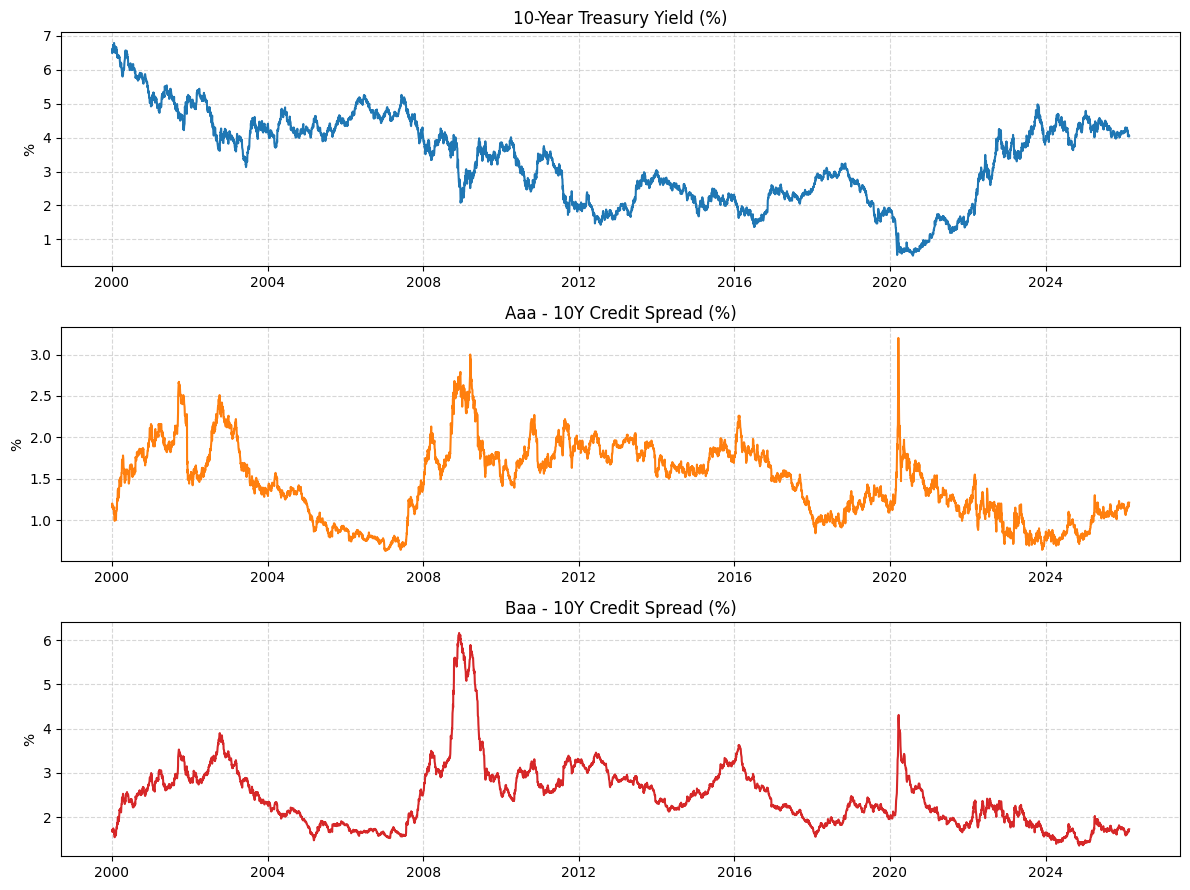

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
variables = ['DGS10', 'AAA10Y', 'BAA10Y']
titles = ['10-Year Treasury Yield (%)', 'Aaa - 10Y Credit Spread (%)', 'Baa - 10Y Credit Spread (%)']
colors = ['tab:blue', 'tab:orange', 'tab:red']

for i, var in enumerate(variables):
    axes[i].plot(tsy_data.index, tsy_data[var], color=colors[i])
    axes[i].set_title(titles[i])
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].set_ylabel('%')
plt.tight_layout()
plt.show()

In [7]:
# Compute first differences (changes)
tsy_changes = tsy_data[['DGS10', 'AAA10Y', 'BAA10Y']].diff().dropna()

# 2. t-распределение

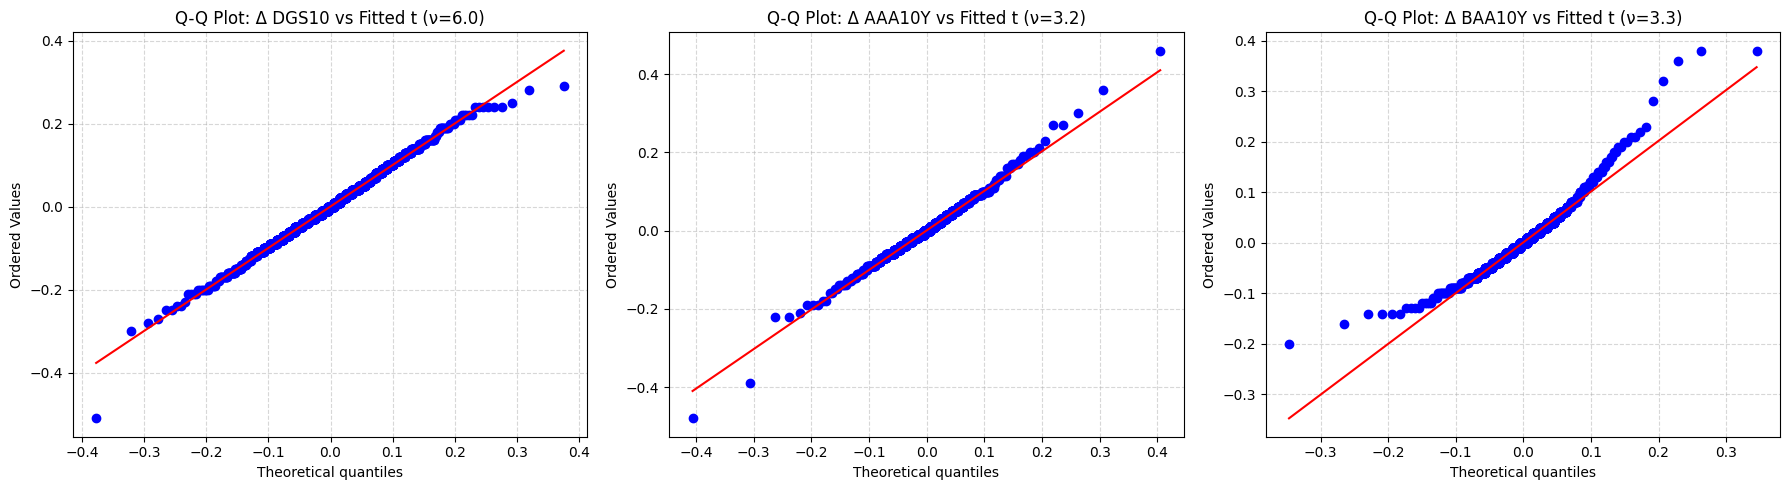


Skewness Comparison: Empirical vs. Theoretical (Fitted t-Distribution)


,Variable,Skew (Empirical),Skew (Theoretical)
0,DGS10,-0.018,0.0
1,AAA10Y,0.244,0.0
2,BAA10Y,1.601,0.0


In [8]:
# --- First: Q-Q plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fit_results = {}  # store fitted params for later use

for i, var in enumerate(['DGS10', 'AAA10Y', 'BAA10Y']):
    data = tsy_changes[var].dropna()
    
    # Fit t-distribution
    df, loc, scale = stats.t.fit(data)
    fit_results[var] = (df, loc, scale)
    
    # Q-Q plot
    stats.probplot(data, dist=stats.t, sparams=(df, loc, scale), plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: Δ {var} vs Fitted t (ν={df:.1f})')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- Second: Build comparison table (SKEW ONLY) ---
results = []

for var in ['DGS10', 'AAA10Y', 'BAA10Y']:
    data = tsy_changes[var].dropna()
    df, loc, scale = fit_results[var]
    
    # Empirical skewness
    emp_skew = stats.skew(data)
    
    # Theoretical skewness from t-distribution
    th_skew = 0.0 if df > 3 else np.nan  # symmetric if df > 3

    results.append({
        'Variable': var,
        'Skew (Empirical)': emp_skew,
        'Skew (Theoretical)': th_skew,
    })

# Create and display simplified table
df_table = pd.DataFrame(results)
df_table = df_table.round({'Skew (Empirical)': 3, 'Skew (Theoretical)': 3})

print("\nSkewness Comparison: Empirical vs. Theoretical (Fitted t-Distribution)")
print("="*65)
df_table

Серьезный недостаток - t-распределение в базовом варианте не учитывает skewness (асимметрию) распределения.

# 3. Jones and Faddy skew-t распределение

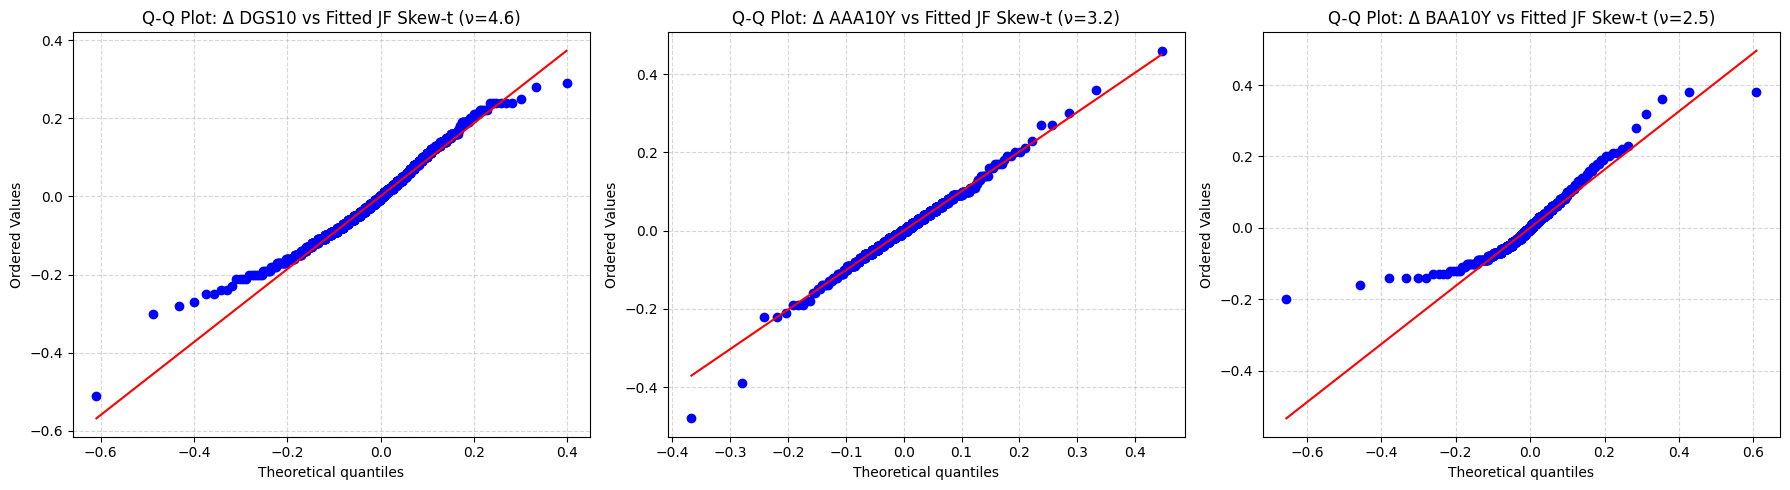


Skewness Comparison: Empirical vs. Theoretical (Fitted Jones–Faddy Skew-t)
Variable  Skew (Empirical)  Skew (Theoretical)
   DGS10            -0.018              -0.886
  AAA10Y             0.244               8.609
  BAA10Y             1.601                 NaN


In [9]:
# --- First: Q-Q plots using jf_skew_t (your preferred style) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fit_results_jf = {}

for i, var in enumerate(['DGS10', 'AAA10Y', 'BAA10Y']):
    data = tsy_changes[var].dropna()
    
    # Fit Jones-Faddy skew-t
    a, b, loc, scale = stats.jf_skew_t.fit(data)
    fit_results_jf[var] = (a, b, loc, scale)
    
    # Q-Q plot (exact style as your original)
    stats.probplot(data, dist=stats.jf_skew_t, sparams=(a, b, loc, scale), plot=axes[i])
    
    nu = a + b
    axes[i].set_title(f'Q-Q Plot: Δ {var} vs Fitted JF Skew-t (ν={nu:.1f})')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- Second: Build comparison table (SKEW ONLY) ---
results_jf = []

for var in ['DGS10', 'AAA10Y', 'BAA10Y']:
    data = tsy_changes[var].dropna()
    a, b, loc, scale = fit_results_jf[var]
    
    # Empirical skewness
    emp_skew = stats.skew(data)
    
    # Theoretical skewness from jf_skew_t
    try:
        th_skew = float(stats.jf_skew_t.stats(a, b, loc=loc, scale=scale, moments='s'))
    except Exception:
        th_skew = np.nan

    results_jf.append({
        'Variable': var,
        'Skew (Empirical)': emp_skew,
        'Skew (Theoretical)': th_skew,
    })

# Create and display simplified table
df_table_jf = pd.DataFrame(results_jf)
df_table_jf = df_table_jf.round({'Skew (Empirical)': 3, 'Skew (Theoretical)': 3})

print("\nSkewness Comparison: Empirical vs. Theoretical (Fitted Jones–Faddy Skew-t)")
print("="*70)
print(df_table_jf.to_string(index=False))

Тест Льюнга-бокса ранее показал наличие авторегресионной условной гетероскедастичности, поэтому даже асимметричное t-распределение работает очень плохо.

# 3. ARCH модели

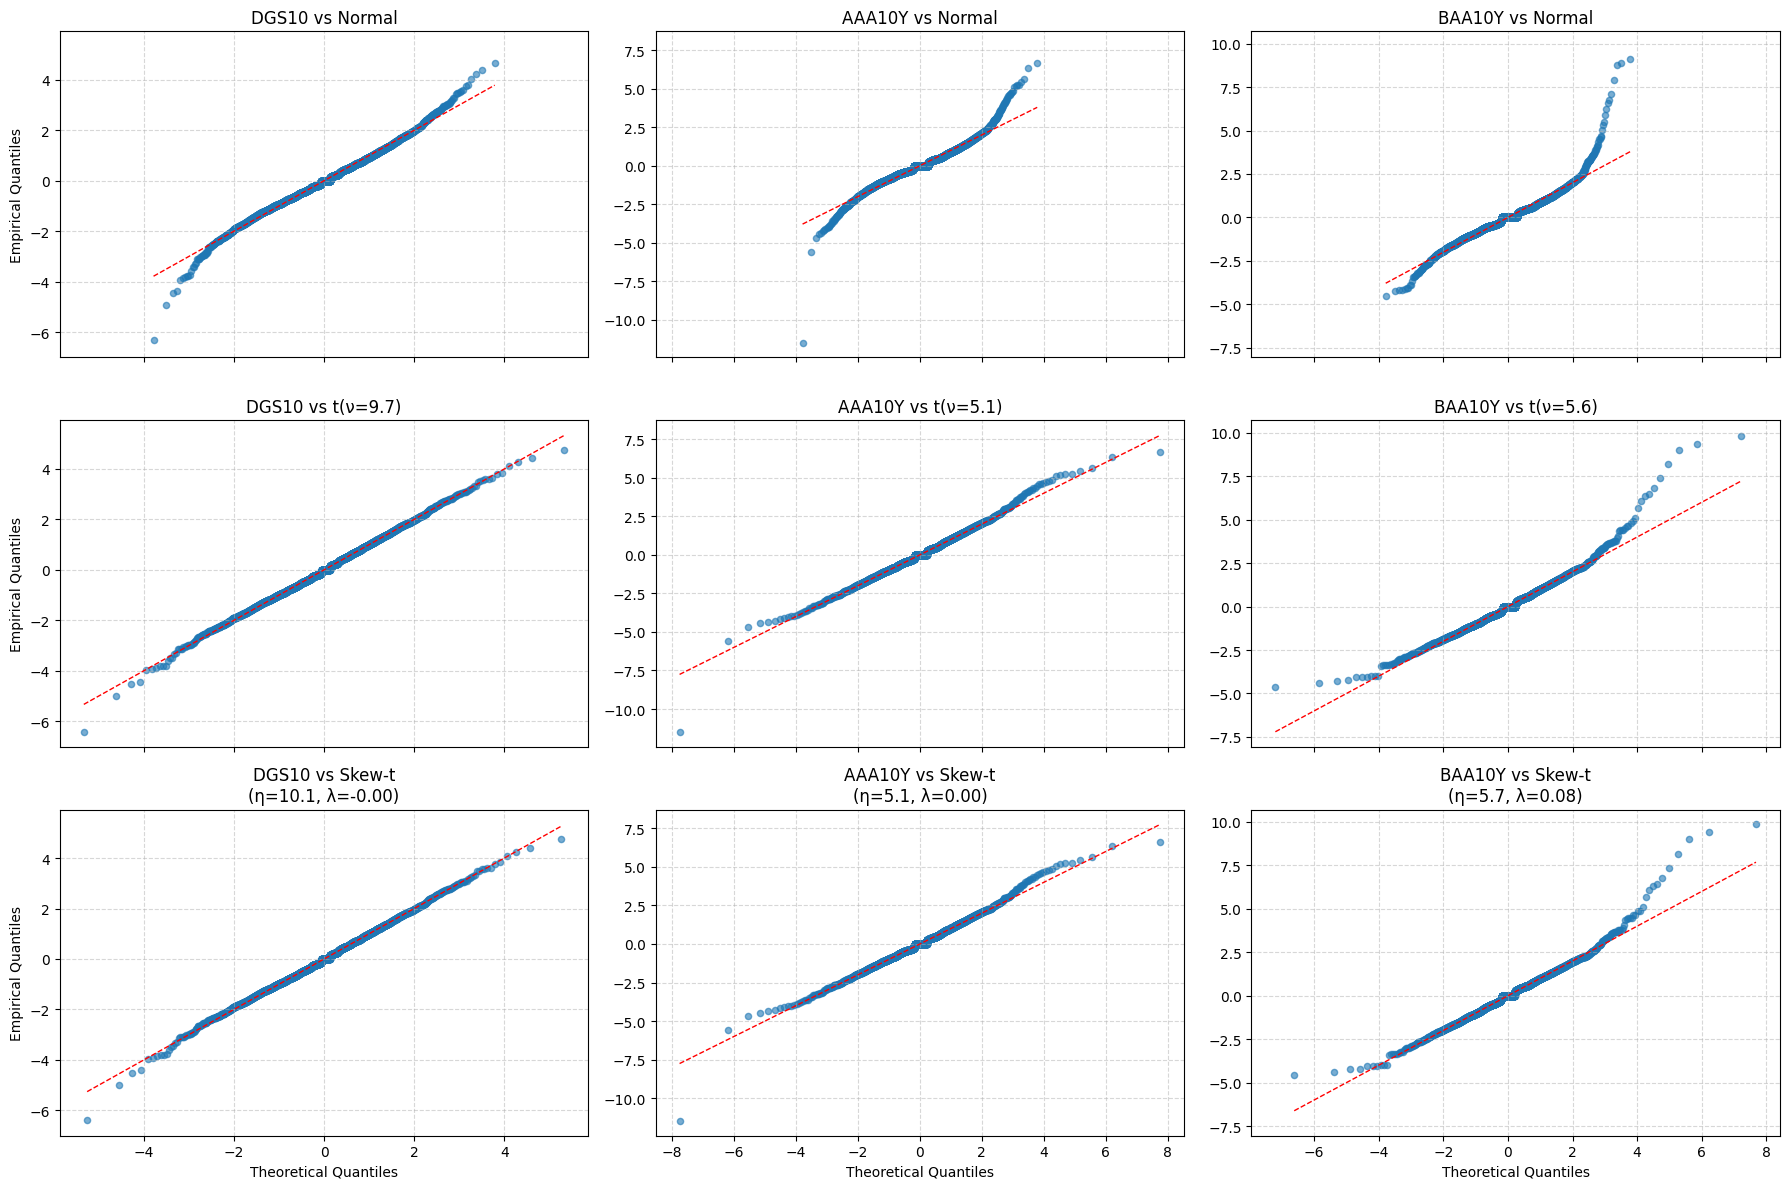

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from arch import arch_model
from arch.univariate import SkewStudent

# Initialize containers
distributions = ['normal', 't', 'skewt']
results = {dist: {} for dist in distributions}
std_resids = {dist: {} for dist in distributions}

# Fit models
for var in ['DGS10', 'AAA10Y', 'BAA10Y']:
    y = tsy_changes[var].dropna()
    
    for dist in distributions:
        model = arch_model(y, mean='Zero', vol='GARCH', p=1, q=1, dist=dist, rescale=False)
        res = model.fit(disp='off')
        results[dist][var] = res
        std_resids[dist][var] = res.resid / res.conditional_volatility

# Create Q-Q plots: one row per distribution, one column per variable
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex='col', sharey='col')
dist_labels = {
    'normal': 'Normal',
    't': 'Student’s t',
    'skewt': 'Skew‑t'
}

# Skew-t distribution object (no params in init)
skewt_dist = SkewStudent()

for i, dist in enumerate(distributions):
    for j, var in enumerate(['DGS10', 'AAA10Y', 'BAA10Y']):
        ax = axes[i, j]
        std_resid = std_resids[dist][var]
        res = results[dist][var]
        
        # Sort empirical residuals
        empirical = np.sort(std_resid)
        n = len(empirical)
        probs = (np.arange(1, n + 1) - 0.5) / n  # Blom's positions

        if dist == 'normal':
            theoretical = stats.norm.ppf(probs)
            title = f'{var} vs Normal'

        elif dist == 't':
            # Extract degrees of freedom (called 'nu' in t, 'eta' in skewt)
            nu = res.params['nu']
            scale = np.sqrt((nu - 2)/nu)
            theoretical = stats.t.ppf(probs, df=nu) * scale
            title = f'{var} vs t(ν={nu:.1f})'

        elif dist == 'skewt':
            eta = res.params['eta']
            lam = res.params['lambda']
            theoretical = skewt_dist.ppf(probs, parameters=[eta, lam])
            title = f'{var} vs Skew-t\n(η={eta:.1f}, λ={lam:.2f})'

        # Plot
        ax.scatter(theoretical, empirical, alpha=0.6, s=20)
        ax.plot(
            [theoretical.min(), theoretical.max()],
            [theoretical.min(), theoretical.max()],
            color='red', linestyle='--', linewidth=1
        )
        ax.set_title(title)
        ax.grid(True, linestyle='--', alpha=0.5)
        if j == 0:
            ax.set_ylabel('Empirical Quantiles')
        if i == 2:
            ax.set_xlabel('Theoretical Quantiles')

plt.tight_layout()
plt.show()

In [11]:
# --- Information Criteria: GARCH(1,1) with Normal / t / Skew-t innovations ---
dist_display = {'normal': 'Normal', 't': "Student's t", 'skewt': 'Skew-t (Hansen)'}

aic_rows, bic_rows = [], []
for var in ['DGS10', 'AAA10Y', 'BAA10Y']:
    aic_row = {'Variable': var}
    bic_row = {'Variable': var}
    for dist in distributions:
        res = results[dist][var]
        aic_row[dist_display[dist]] = round(res.aic, 1)
        bic_row[dist_display[dist]] = round(res.bic, 1)
    aic_rows.append(aic_row)
    bic_rows.append(bic_row)

df_bic = pd.DataFrame(bic_rows).set_index('Variable')

def bold_min(row):
    """Bold the cell with the lowest value in each row."""
    return ['font-weight: bold' if v == row.min() else '' for v in row]

print("\nBIC — lower is better  (best highlighted per series)")
display(df_bic.style.apply(bold_min, axis=1).format("{:.1f}"))



BIC — lower is better  (best highlighted per series)


,Normal,Student's t,Skew-t (Hansen)
Variable,,,
DGS10,-19599.1,-19708.8,-19703.0
AAA10Y,-27731.4,-28410.1,-28401.3
BAA10Y,-28884.8,-29550.2,-29561.4


Информационный критерий BIC показал интересные результаты.

Для доходностей американский Treasuries и для спредов AAA облигаций t-распределение является более подходящим - параметр асимметрии в skew-t распределении конечно же улучшает соответствие теоретического и практического распределения, однако этого не достаточно чтобы обосновать использование дополнительного параметра этого распределения.

Для спредов BAA облигаций распределение skew-t по критерию BIC является более подходящим, однако глядя на QQ графики видим, что теоретическое распределение очень далеко от эмпирического. 

Трудности с моделированием BAA спредов не являются случайными - они отражают принципиально иную природу этого инструмента. BAA облигации находятся на нижней границе инвестиционного рейтинга. Их спред включает не только кредитную премию, но и риск смены рейтинга, чувствительность к фазе кредитного цикла и существенную компоненту ликвидности. Нелинейные, скачкообразные расширения спреда в периоды стресса выходят за рамки возможностей стандартных ARCH моделей, что и объясняет неудовлетворительное качество подгонки.

По совокупности статистических и экономических оснований дальнейший анализ сосредоточен на паре DGS10 и AAA10Y.

# 4. Финальный выбор распределений: GARCH(1,1)-t

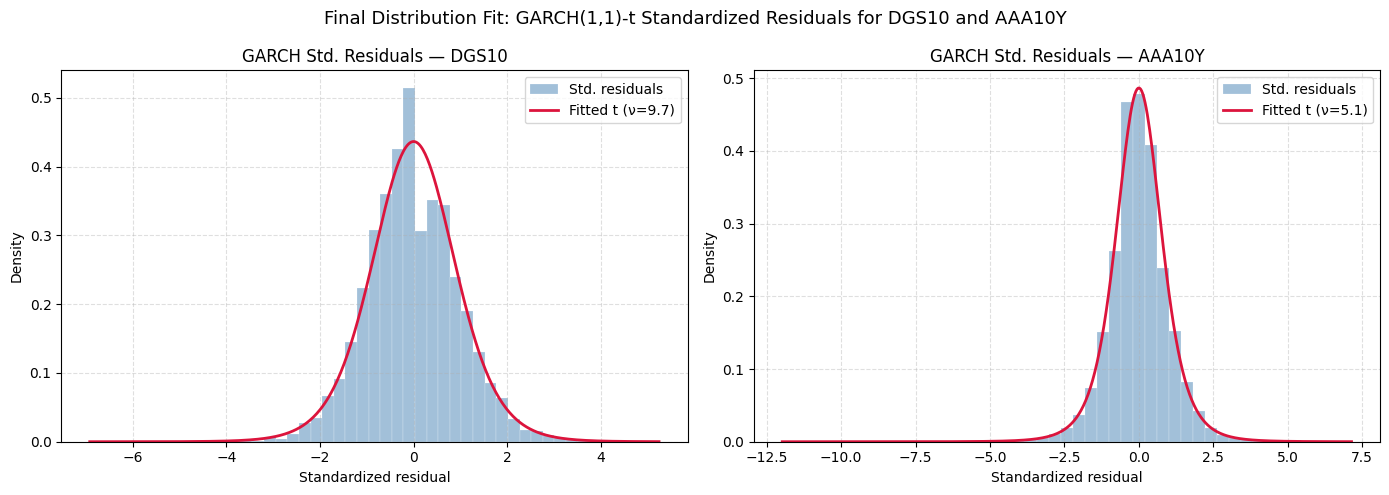

In [12]:
# Histogram of GARCH(1,1)-t standardized residuals + fitted t-distribution PDF
# BIC selected Student's t for both DGS10 and AAA10Y

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var in zip(axes, ['DGS10', 'AAA10Y']):
    resid = std_resids['t'][var].values
    nu    = results['t'][var].params['nu']

    # Histogram (density=True so it integrates to 1)
    ax.hist(resid, bins=45, density=True, color='steelblue', alpha=0.5,
            edgecolor='white', linewidth=0.3, label='Std. residuals')

    # Fitted t-distribution PDF
    # arch scales the t so that Var=1: z ~ t(nu) * sqrt((nu-2)/nu)
    scale = np.sqrt((nu - 2) / nu)
    x = np.linspace(resid.min() - 0.5, resid.max() + 0.5, 500)
    pdf = stats.t.pdf(x, df=nu, loc=0, scale=scale)
    ax.plot(x, pdf, color='crimson', linewidth=2,
            label=f'Fitted t (ν={nu:.1f})')

    ax.set_title(f'GARCH Std. Residuals — {var}')
    ax.set_xlabel('Standardized residual')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Final Distribution Fit: GARCH(1,1)-t Standardized Residuals for DGS10 and AAA10Y',
             fontsize=13,)
plt.tight_layout()
plt.show()


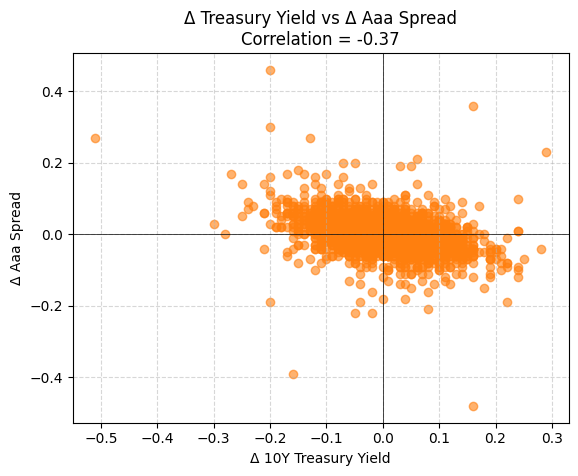

In [16]:
corr_aaa = tsy_changes['DGS10'].corr(tsy_changes['AAA10Y'])
plt.scatter(tsy_changes['DGS10'], tsy_changes['AAA10Y'], alpha=0.6, color='tab:orange')
plt.xlabel('Δ 10Y Treasury Yield')
plt.ylabel('Δ Aaa Spread')
plt.title(f'Δ Treasury Yield vs Δ Aaa Spread\nCorrelation = {corr_aaa:.2f}')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.5)


# 5. GARCH(1,1)-t: Итоговые параметры

In [17]:
# GARCH(1,1)-t estimated parameters for the selected pair: DGS10 and AAA10Y
summary_rows = []

for var in ['DGS10', 'AAA10Y']:
    res = results['t'][var]
    params = res.params
    omega   = params['omega']
    alpha   = params['alpha[1]']
    beta    = params['beta[1]']
    nu      = params['nu']
    persist = alpha + beta
    long_run_vol = (omega / (1 - persist))**0.5 * 100 * np.sqrt(252) if persist < 1 else float('nan')

    summary_rows.append({
        'Variable':               var,
        'ω (long-run var)':       f'{omega:.2e}',
        'α (shock)':              f'{alpha:.3f}',
        'β (persistence)':        f'{beta:.3f}',
        'α + β':                  f'{persist:.3f}',
        'ν (tail d.f.)':          f'{nu:.2f}',
        'Long-run vol (bps, ann.)': f'{long_run_vol:.2f}',
    })

pd.DataFrame(summary_rows).set_index('Variable')

,ω (long-run var),α (shock),β (persistence),α + β,ν (tail d.f.),"Long-run vol (bps, ann.)"
Variable,,,,,,
DGS10,6.71e-05,0.050,0.928,0.978,9.68,87.92
AAA10Y,2.30e-05,0.100,0.880,0.980,5.13,53.87
